  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

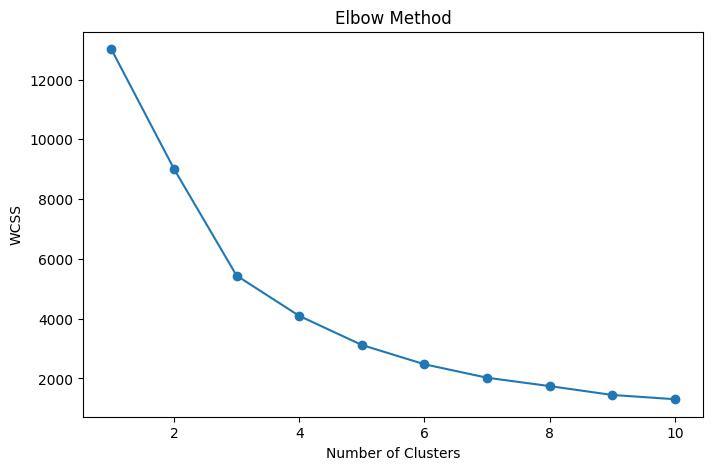

Silhouette Score: 0.616212846765192

Cluster Summary
            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490


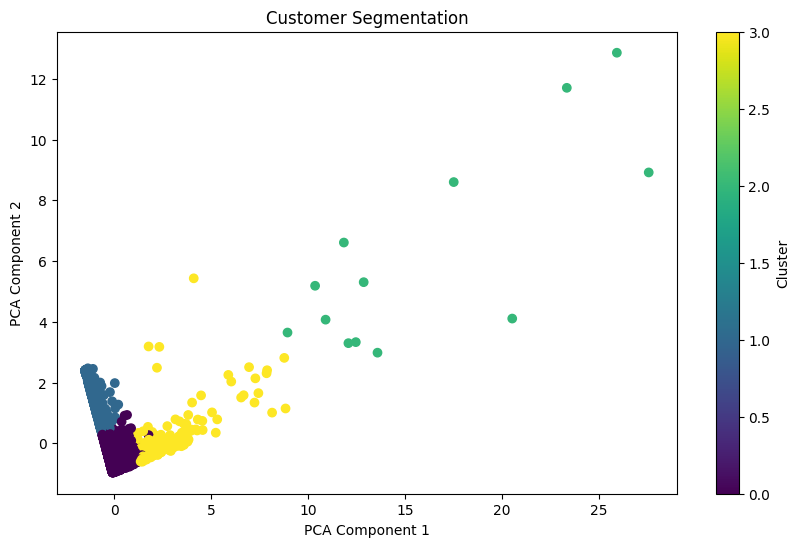

   CustomerID  Recency  Frequency  Monetary         Country  Cluster  \
0     12346.0      326          1  77183.60  United Kingdom        3   
1     12347.0        2          7   4310.00         Iceland        0   
2     12348.0       75          4   1797.24         Finland        0   
3     12349.0       19          1   1757.55           Italy        0   
4     12350.0      310          1    334.40          Norway        1   

       PCA1      PCA2           Segment  
0  4.106623  5.433579  Budget Customers  
1  0.742411 -0.671300   Loyal Customers  
2  0.024802 -0.174954   Loyal Customers  
3 -0.028036 -0.735124   Loyal Customers  
4 -1.235466  1.834946     VIP Customers  

Customer segmentation completed!


In [1]:
# =============================
# CUSTOMER SEGMENTATION PROJECT
# =============================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# -----------------------------
# 1. Load Dataset
# -----------------------------

df = pd.read_excel("/content/Online Retail.xlsx")

print(df.head())
print(df.info())

# -----------------------------
# 2. Data Cleaning
# -----------------------------

# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative quantity
df = df[df['Quantity'] > 0]

# Remove zero/negative prices
df = df[df['UnitPrice'] > 0]

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalAmount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# -----------------------------
# 3. Create RFM Features
# -----------------------------

# Reference date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Recency
recency = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency['Recency'] = (
    snapshot_date - recency['InvoiceDate']
).dt.days

# Frequency
frequency = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency.columns = ['CustomerID', 'Frequency']

# Monetary
monetary = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()
monetary.columns = ['CustomerID', 'Monetary']

# Country (Demographic feature)
country = df.groupby('CustomerID')['Country'].first().reset_index()

# Merge RFM data
customer_df = recency[['CustomerID', 'Recency']] \
    .merge(frequency, on='CustomerID') \
    .merge(monetary, on='CustomerID') \
    .merge(country, on='CustomerID')

print(customer_df.head())

# -----------------------------
# 4. Feature Scaling
# -----------------------------

features = customer_df[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# -----------------------------
# 5. Elbow Method
# -----------------------------

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# -----------------------------
# 6. K-Means Clustering
# -----------------------------

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

customer_df['Cluster'] = kmeans.fit_predict(
    scaled_features
)

# -----------------------------
# 7. Silhouette Score
# -----------------------------

score = silhouette_score(
    scaled_features,
    customer_df['Cluster']
)

print("Silhouette Score:", score)

# -----------------------------
# 8. Cluster Analysis
# -----------------------------

cluster_summary = customer_df.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

print("\nCluster Summary")
print(cluster_summary)

# -----------------------------
# 9. PCA for Visualization
# -----------------------------

pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

customer_df['PCA1'] = pca_features[:, 0]
customer_df['PCA2'] = pca_features[:, 1]

# Scatter Plot
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    customer_df['PCA1'],
    customer_df['PCA2'],
    c=customer_df['Cluster']
)

plt.title('Customer Segmentation')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

# -----------------------------
# 10. Label Customer Segments
# -----------------------------

def segment_name(cluster):
    if cluster == 0:
        return "Loyal Customers"
    elif cluster == 1:
        return "VIP Customers"
    elif cluster == 2:
        return "At Risk Customers"
    else:
        return "Budget Customers"

customer_df['Segment'] = customer_df['Cluster'].apply(
    segment_name
)

print(customer_df.head())

# Save output
customer_df.to_csv(
    "customer_segments.csv",
    index=False
)

print("\nCustomer segmentation completed!")